# 🌾 Crop Yield Predictor — India
## Predicting Crop Yield across Indian States using Machine Learning

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import os
os.chdir(r'C:\Users\admin\OneDrive\Desktop\CropYield-Project')

## 2. Loading the Dataset

In [3]:
df = pd.read_csv('Crop Yeild Data.csv')
df.head()

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796,23.692,33.435,14.779
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710,23.692,33.435,14.779
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238,23.692,33.435,14.779
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.052,23.692,33.435,14.779
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.421,23.692,33.435,14.779


## 3. Exploring the Dataset

In [4]:
print("Shape:", df.shape)
print("\nNumber of States:", df['State'].nunique())
print("Number of Crops:", df['Crop'].nunique())
print("Number of Seasons:", df['Season'].nunique())
print("\nYear Range:", df['Crop_Year'].min(), "to", df['Crop_Year'].max())
print("\nMissing Values:\n", df.isnull().sum())

Shape: (19689, 13)

Number of States: 30
Number of Crops: 55
Number of Seasons: 6

Year Range: 1997 to 2020

Missing Values:
 Crop               0
Crop_Year          0
Season             0
State              0
Area               0
Production         0
Annual_Rainfall    0
Fertilizer         0
Pesticide          0
Yield              0
Avg_Temperature    0
Max_Temperature    0
Min_Temperature    0
dtype: int64


In [5]:
df.describe()

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield,Avg_Temperature,Max_Temperature,Min_Temperature
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000,19689.000000,19689.000000,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.755186,2.410331e+07,4.884835e+04,79.954011,23.831279,33.947314,14.723357
std,6.498099,7.328287e+05,2.630568e+08,816.909592,9.494600e+07,2.132874e+05,878.306194,5.847672,5.732339,6.571713
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000,-5.115000,7.701000,-19.359000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000,23.545000,32.483000,13.535000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000,25.675000,35.826000,15.890000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.389000,26.413000,37.265000,16.983000
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000,28.652000,40.632000,24.972000


In [6]:
print("Seasons:", df['Season'].unique())
print("\nTop 10 Crops:\n", df['Crop'].value_counts().head(10))

Seasons: ['Whole Year ' 'Kharif     ' 'Rabi       ' 'Autumn     ' 'Summer     '
 'Winter     ']

Top 10 Crops:
 Crop
Rice                 1197
Maize                 975
Moong(Green Gram)     740
Urad                  733
Groundnut             725
Sesamum               685
Potato                628
Sugarcane             605
Wheat                 545
Rapeseed &Mustard     528
Name: count, dtype: int64


## 4. Exploratory Data Analysis (EDA)

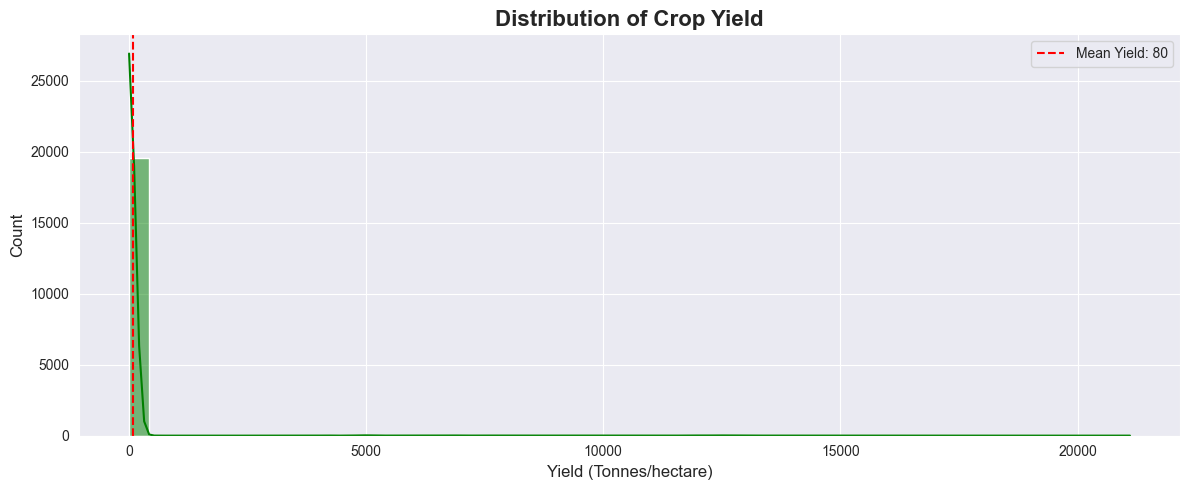

In [7]:
sns.set_style('darkgrid')
plt.figure(figsize=(12,5))
sns.histplot(df['Yield'], bins=50, color='green', kde=True)
plt.title('Distribution of Crop Yield', fontsize=16, fontweight='bold')
plt.xlabel('Yield (Tonnes/hectare)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.axvline(df['Yield'].mean(), color='red', linestyle='--', label=f"Mean Yield: {df['Yield'].mean():.0f}")
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_13372\3341081476.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_crops.values, y=top_crops.index, palette='Greens_r')


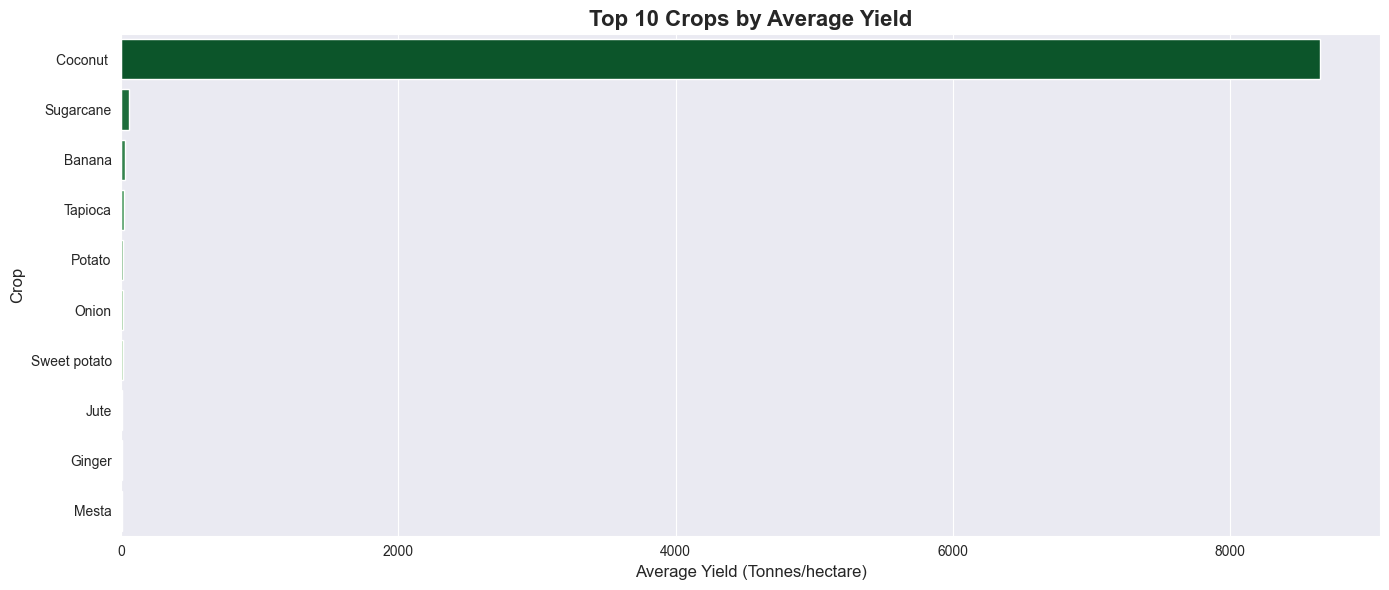

In [8]:
plt.figure(figsize=(14,6))
top_crops = df.groupby('Crop')['Yield'].mean().sort_values(ascending=False).head(10)
sns.barplot(x=top_crops.values, y=top_crops.index, palette='Greens_r')
plt.title('Top 10 Crops by Average Yield', fontsize=16, fontweight='bold')
plt.xlabel('Average Yield (Tonnes/hectare)', fontsize=12)
plt.ylabel('Crop', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_13372\2835678501.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=state_yield.values, y=state_yield.index, palette='Greens_r')


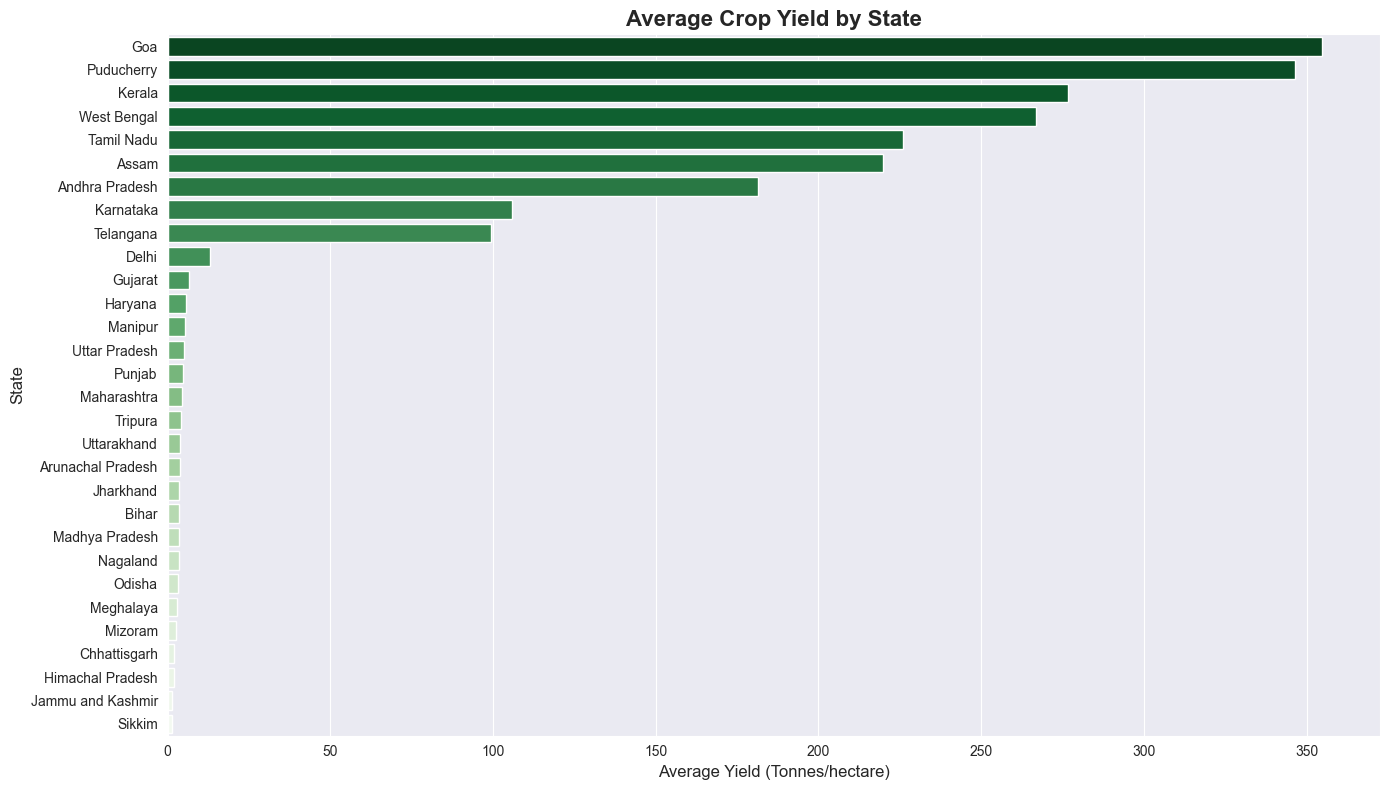

In [9]:
plt.figure(figsize=(14,8))
state_yield = df.groupby('State')['Yield'].mean().sort_values(ascending=False)
sns.barplot(x=state_yield.values, y=state_yield.index, palette='Greens_r')
plt.title('Average Crop Yield by State', fontsize=16, fontweight='bold')
plt.xlabel('Average Yield (Tonnes/hectare)', fontsize=12)
plt.ylabel('State', fontsize=12)
plt.tight_layout()
plt.show()

C:\Users\admin\AppData\Local\Temp\ipykernel_13372\2158775790.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_yield.index, y=season_yield.values, palette='Greens_r')


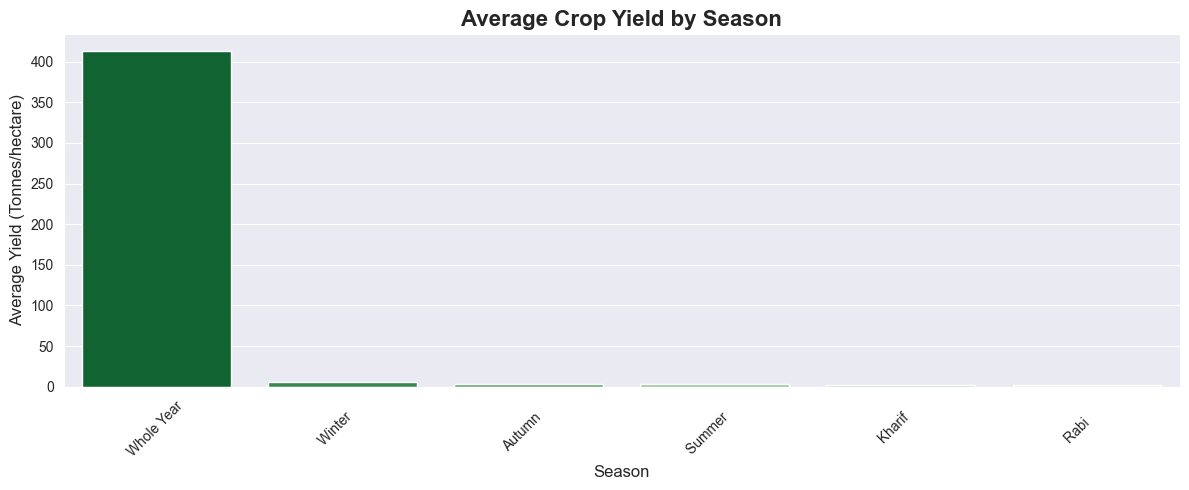

In [10]:
plt.figure(figsize=(12,5))
season_yield = df.groupby('Season')['Yield'].mean().sort_values(ascending=False)
sns.barplot(x=season_yield.index, y=season_yield.values, palette='Greens_r')
plt.title('Average Crop Yield by Season', fontsize=16, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Average Yield (Tonnes/hectare)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

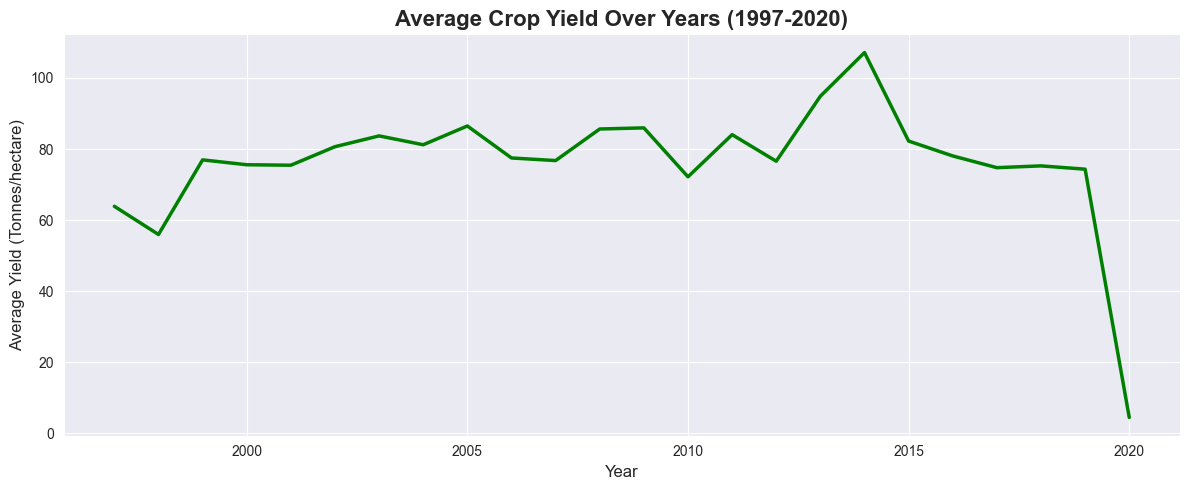

In [11]:
plt.figure(figsize=(12,5))
sns.lineplot(data=df.groupby('Crop_Year')['Yield'].mean().reset_index(), 
             x='Crop_Year', y='Yield', color='green', linewidth=2.5)
plt.title('Average Crop Yield Over Years (1997-2020)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Yield (Tonnes/hectare)', fontsize=12)
plt.tight_layout()
plt.show()

In [12]:
print(df['Crop_Year'].value_counts().sort_index())

Crop_Year
1997     410
1998     646
1999     650
2000     772
2001     750
2002     815
2003     801
2004     787
2005     811
2006     823
2007     828
2008     847
2009     865
2010     859
2011     907
2012     894
2013     976
2014     965
2015     998
2016    1036
2017    1070
2018    1063
2019    1079
2020      37
Name: count, dtype: int64


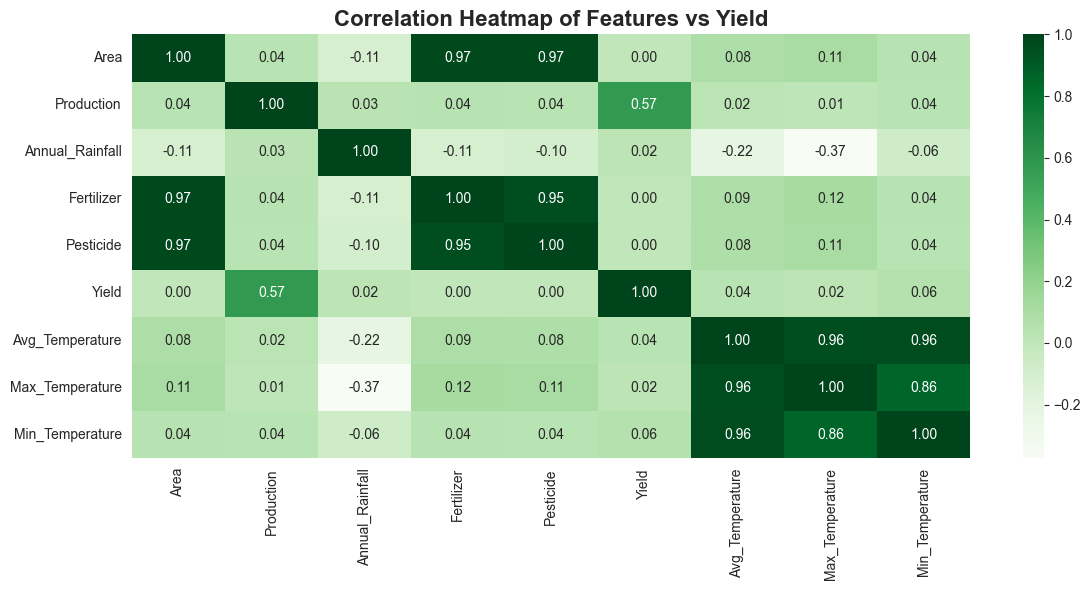

In [13]:
plt.figure(figsize=(12,6))
correlation = df[['Area','Production','Annual_Rainfall','Fertilizer','Pesticide','Yield','Avg_Temperature','Max_Temperature','Min_Temperature']].corr()
sns.heatmap(correlation, annot=True, cmap='Greens', fmt='.2f')
plt.title('Correlation Heatmap of Features vs Yield', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

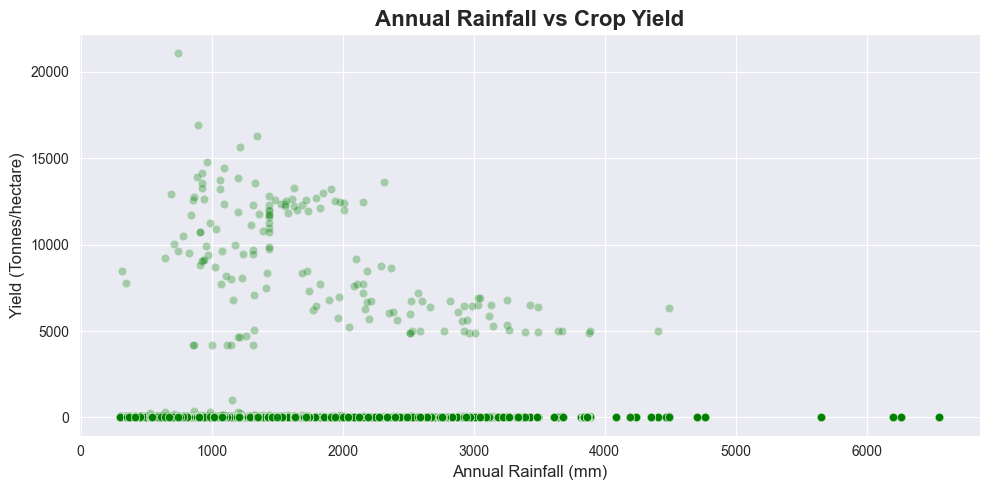

In [14]:
plt.figure(figsize=(10,5))
sns.scatterplot(x=df['Annual_Rainfall'], y=df['Yield'], alpha=0.3, color='green')
plt.title('Annual Rainfall vs Crop Yield', fontsize=16, fontweight='bold')
plt.xlabel('Annual Rainfall (mm)', fontsize=12)
plt.ylabel('Yield (Tonnes/hectare)', fontsize=12)
plt.tight_layout()
plt.show()

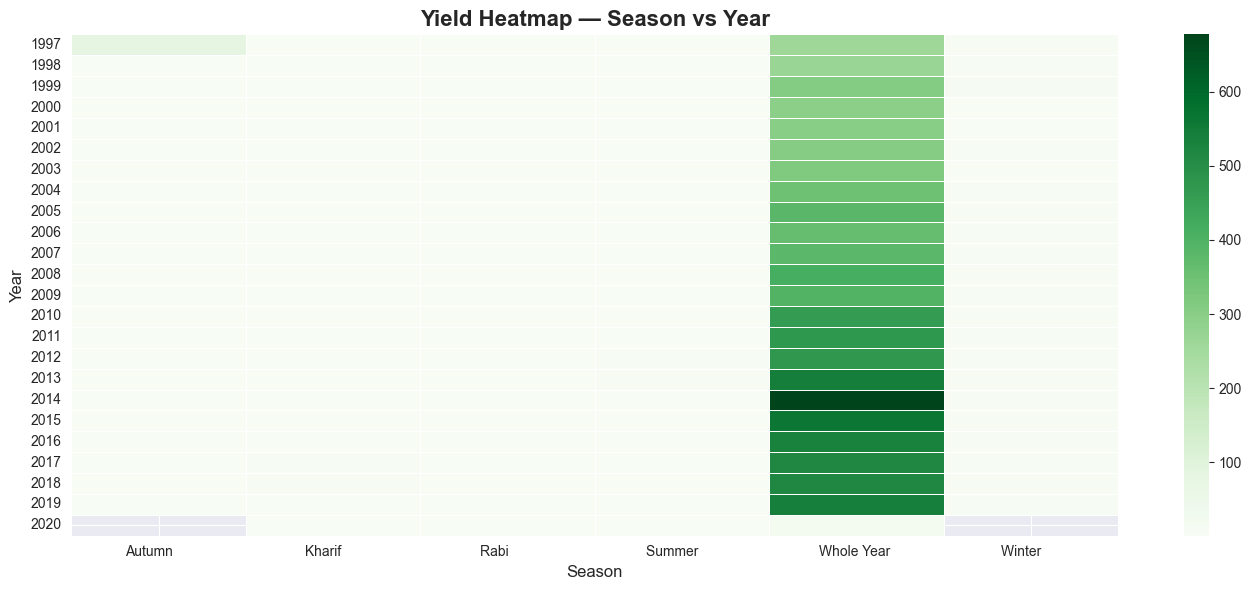

In [15]:
plt.figure(figsize=(14,6))
season_year = df.groupby(['Crop_Year','Season'])['Yield'].mean().unstack()
sns.heatmap(season_year, cmap='Greens', linewidths=0.5)
plt.title('Yield Heatmap — Season vs Year', fontsize=16, fontweight='bold')
plt.xlabel('Season', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.tight_layout()
plt.show()

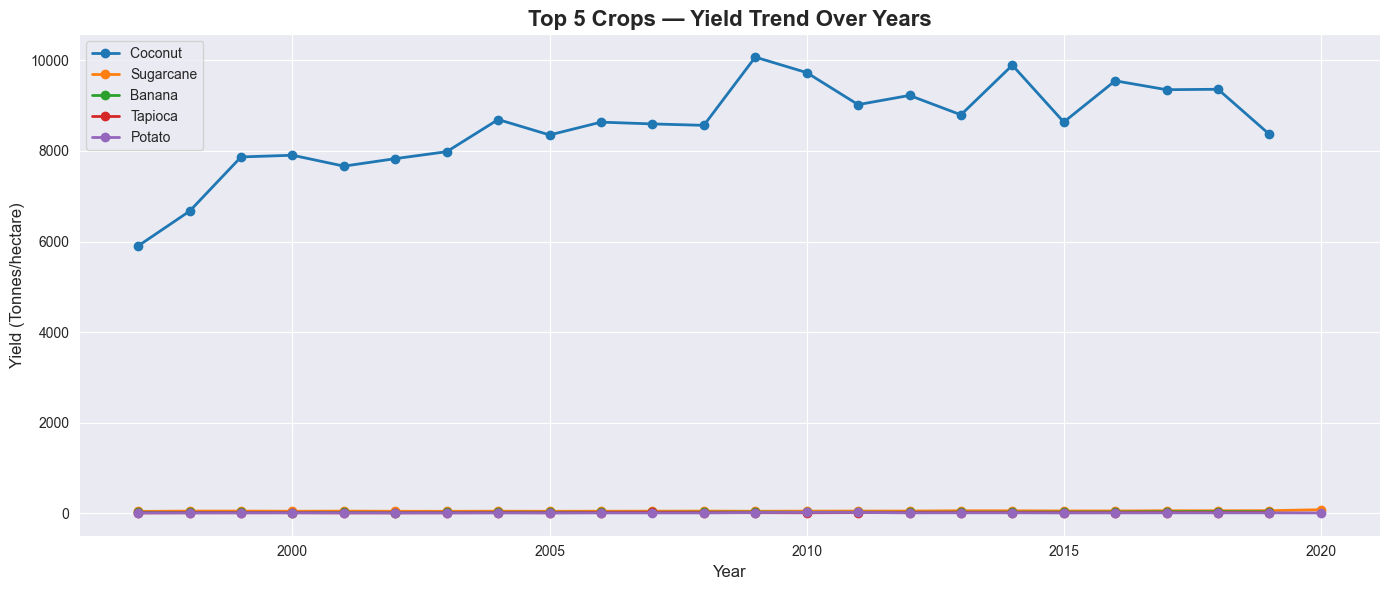

In [16]:
top5_crops = df.groupby('Crop')['Yield'].mean().sort_values(ascending=False).head(5).index

plt.figure(figsize=(14,6))
for crop in top5_crops:
    crop_data = df[df['Crop']==crop].groupby('Crop_Year')['Yield'].mean()
    plt.plot(crop_data.index, crop_data.values, marker='o', label=crop, linewidth=2)

plt.title('Top 5 Crops — Yield Trend Over Years', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Yield (Tonnes/hectare)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

## 5. Data Cleaning & Feature Engineering

### 5.1 Drop Incomplete 2020 Data


In [17]:
df = df[df['Crop_Year'] != 2020]
print("After dropping 2020:", df.shape)

After dropping 2020: (19652, 13)


### 5.2 Drop Production Column (Prevents Data Leakage)

In [18]:
df = df.drop(columns=['Production'])
print("After dropping Production:", df.shape)

After dropping Production: (19652, 12)


### 5.3 Feature Engineering — Temperature Range

In [19]:
df['Temp_Range'] = df['Max_Temperature'] - df['Min_Temperature']
print("Temperature Range feature added!")

Temperature Range feature added!


### 5.4 Check Duplicates

In [20]:
print("Duplicates:", df.duplicated().sum())

print("\nFinal columns:", df.columns.tolist())

Duplicates: 0

Final columns: ['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield', 'Avg_Temperature', 'Max_Temperature', 'Min_Temperature', 'Temp_Range']


### 5.5 Handling Outliers (IQR Method)

In [21]:

Q1 = df['Yield'].quantile(0.25)
Q3 = df['Yield'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Yield'] < lower) | (df['Yield'] > upper)]
print("Number of outliers:", len(outliers))
print("Lower bound:", round(lower, 2))
print("Upper bound:", round(upper, 2))

Number of outliers: 3060
Lower bound: -2.09
Upper bound: 5.08


### 5.5 Handling Outliers — Winsorization (IQR Capping)

In [22]:

df['Yield'] = df['Yield'].clip(lower=lower, upper=upper)
print("Outliers capped!")
print("Max Yield after capping:", df['Yield'].max())
print("Min Yield after capping:", df['Yield'].min())

Outliers capped!
Max Yield after capping: 5.0771250000000006
Min Yield after capping: 0.0


### 5.6 Label Encoding — Categorical Features

In [23]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Crop'] = le.fit_transform(df['Crop'])
df['Season'] = le.fit_transform(df['Season'])
df['State'] = le.fit_transform(df['State'])

print("Label Encoding done!")
print(df.head())

Label Encoding done!
   Crop  Crop_Year  Season  State     Area  Annual_Rainfall  Fertilizer  \
0     0       1997       4      2  73814.0           2051.4  7024878.38   
1     1       1997       1      2   6637.0           2051.4   631643.29   
2     8       1997       1      2    796.0           2051.4    75755.32   
3     9       1997       4      2  19656.0           2051.4  1870661.52   
4    11       1997       1      2   1739.0           2051.4   165500.63   

   Pesticide     Yield  Avg_Temperature  Max_Temperature  Min_Temperature  \
0   22882.34  0.796000           23.692           33.435           14.779   
1    2057.47  0.710000           23.692           33.435           14.779   
2     246.76  0.238000           23.692           33.435           14.779   
3    6093.36  5.077125           23.692           33.435           14.779   
4     539.09  0.421000           23.692           33.435           14.779   

   Temp_Range  
0      18.656  
1      18.656  
2      18.656  
3

## 6. Post-Cleaning EDA


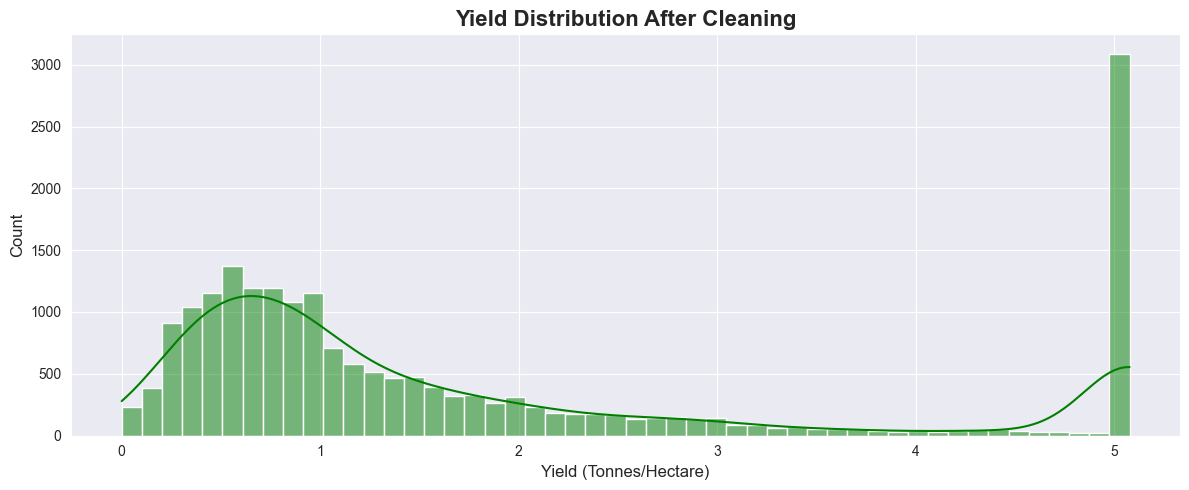

In [24]:
plt.figure(figsize=(12,5))
sns.histplot(df['Yield'], bins=50, color='green', kde=True)
plt.title('Yield Distribution After Cleaning', fontsize=16, fontweight='bold')
plt.xlabel('Yield (Tonnes/Hectare)', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

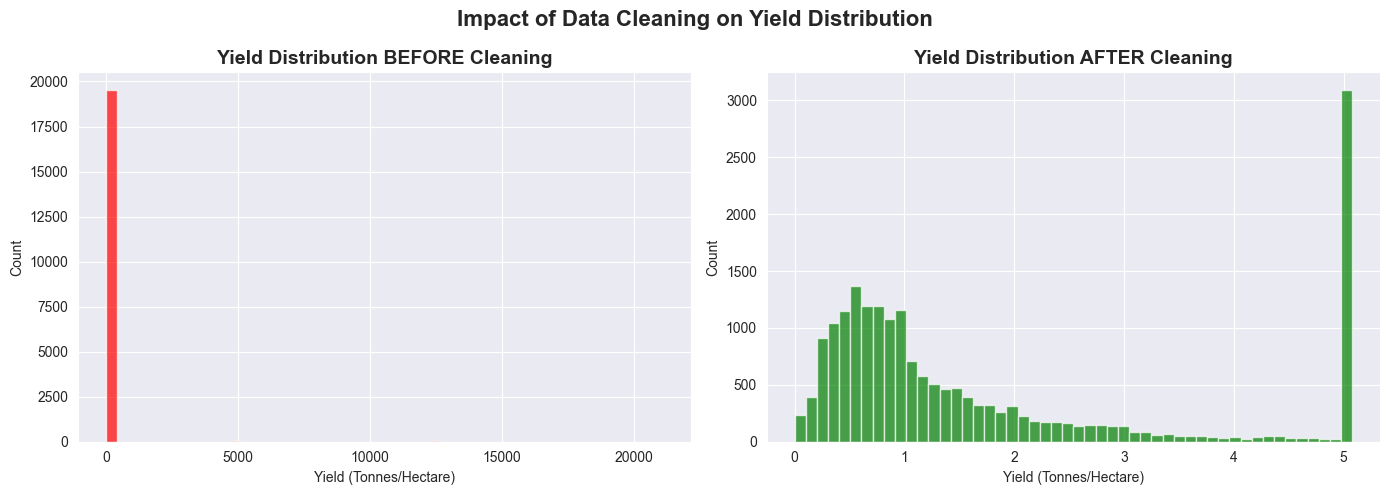

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

# Before cleaning - reload original
df_original = pd.read_csv('Crop Yeild Data.csv')
axes[0].hist(df_original['Yield'], bins=50, color='red', alpha=0.7)
axes[0].set_title('Yield Distribution BEFORE Cleaning', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Yield (Tonnes/Hectare)')
axes[0].set_ylabel('Count')

# After cleaning
axes[1].hist(df['Yield'], bins=50, color='green', alpha=0.7)
axes[1].set_title('Yield Distribution AFTER Cleaning', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Yield (Tonnes/Hectare)')
axes[1].set_ylabel('Count')

plt.suptitle('Impact of Data Cleaning on Yield Distribution', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Model Building

In [26]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Yield'])
y = df['Yield']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (15721, 12)
Testing size: (3931, 12)


### 7.1 Linear Regression

In [27]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression R²:", round(r2_lr, 2))
print("Linear Regression RMSE:", round(rmse_lr, 2))

Linear Regression R²: 0.14
Linear Regression RMSE: 1.53


### 7.2 Random Forest

In [28]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest R²:", round(r2_rf, 2))
print("Random Forest RMSE:", round(rmse_rf, 2))

Random Forest R²: 0.92
Random Forest RMSE: 0.48


### 7.3 XGBoost

In [29]:
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

r2_xgb = r2_score(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))

print("XGBoost R²:", round(r2_xgb, 2))
print("XGBoost RMSE:", round(rmse_xgb, 2))

XGBoost R²: 0.91
XGBoost RMSE: 0.51


## 8. Model Comparison

C:\Users\admin\AppData\Local\Temp\ipykernel_13372\3810311533.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models, y=r2_scores, palette='Greens_r')


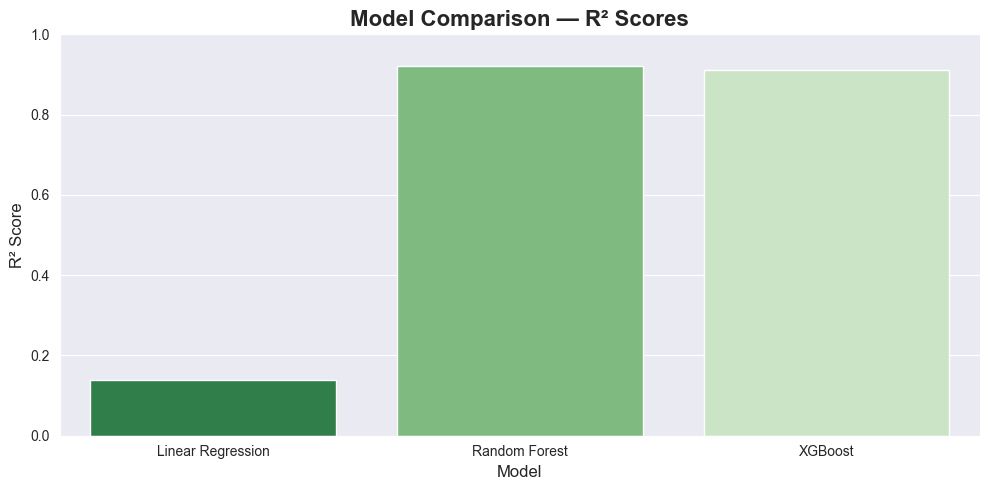

In [30]:
models = ['Linear Regression', 'Random Forest', 'XGBoost']
r2_scores = [0.14, 0.92, 0.91]

plt.figure(figsize=(10,5))
sns.barplot(x=models, y=r2_scores, palette='Greens_r')
plt.title('Model Comparison — R² Scores', fontsize=16, fontweight='bold')
plt.xlabel('Model', fontsize=12)
plt.ylabel('R² Score', fontsize=12)
plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

## 9. Feature Importance

C:\Users\admin\AppData\Local\Temp\ipykernel_13372\2425532245.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='Greens_r')


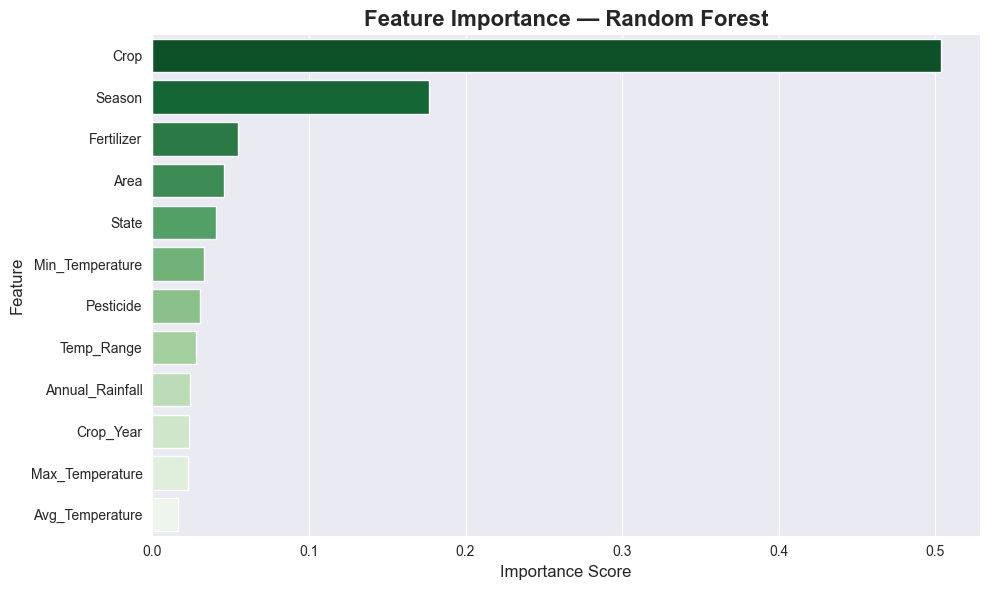

In [31]:
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='Greens_r')
plt.title('Feature Importance — Random Forest', fontsize=16, fontweight='bold')
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

## 10. Actual vs Predicted

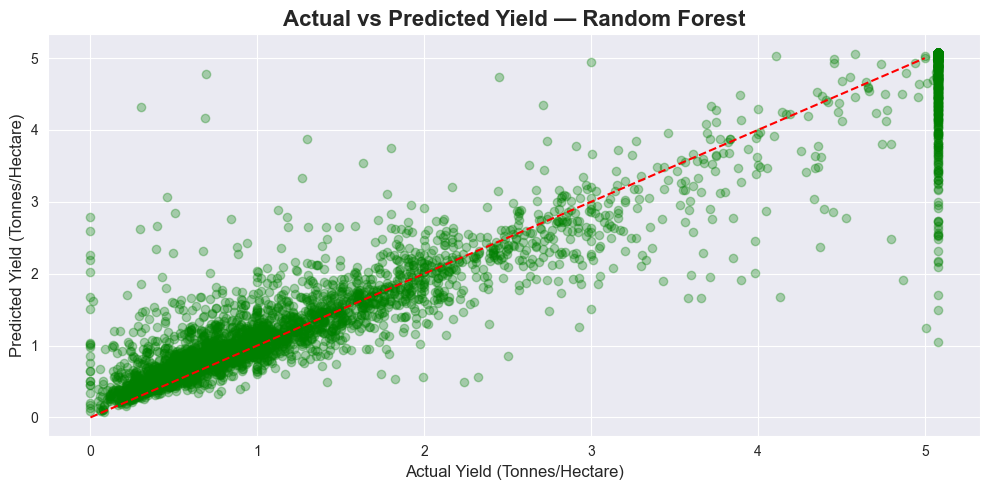

In [32]:
plt.figure(figsize=(10,5))
plt.scatter(y_test, y_pred_rf, alpha=0.3, color='green')
plt.plot([0, 5], [0, 5], color='red', linestyle='--')
plt.title('Actual vs Predicted Yield — Random Forest', fontsize=16, fontweight='bold')
plt.xlabel('Actual Yield (Tonnes/Hectare)', fontsize=12)
plt.ylabel('Predicted Yield (Tonnes/Hectare)', fontsize=12)
plt.tight_layout()
plt.show()